# DS-03 · Mall Customer Segmentation
**Team:** _add names_   |   **Date:** 30 September 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.max_columns", 50)

# Figures are saved to reports/figures (repo layout) so they can be used in the README and slides
FIG_DIR = Path("../reports/figures") if Path("../data").exists() else Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def find_data(name):
    """Look in data/ first; in Colab without the repo, show a Choose Files button."""
    for p in [Path("../data") / name, Path("data") / name, Path(name)]:
        if p.exists():
            return p
    try:
        from google.colab import files
        print(f"Please upload {name}")
        up = files.upload()
        return Path(list(up.keys())[0])
    except ImportError:
        raise FileNotFoundError(f"Put {name} in the data/ folder")

path = find_data("mall_customers.csv")
df_raw = pd.read_csv(path)
print("Loaded", path, "→ shape", df_raw.shape)

Loaded ../data/mall_customers.csv → shape (200, 5)


## 1. Problem statement
**Client:** a shopping mall's marketing team currently sends the **same promotion to every member**.

**Business question:** What natural customer groups exist based on income, spending and age, and what marketing action suits each group?

- **Task type:** unsupervised clustering. There is **no target variable** and no positive class.
- **Success metric:** the **silhouette score** (−1 to 1; higher = customers are close to their own group and far from other groups), plus a business test: every cluster must be **distinct enough to get its own campaign**.
- **Why this metric:** without labels we cannot measure accuracy. Silhouette measures how well separated the groups are, and it lets us compare a simple rule-based segmentation (baseline) with K-Means on the same scale.

## 2. Data dictionary
| Column | Meaning | Type | Unit | Notes |
|---|---|---|---|---|
| CustomerID | Member identifier | integer | id | Not used for clustering |
| Gender | Customer gender | category | Male / Female | Misspelled as `Genre` in the file → renamed |
| Age | Customer age | integer | years | 18–70 |
| Income | Annual income | integer | thousand $ | Original name `Annual Income (k$)` |
| Spending | Spending score assigned by the mall from purchase behaviour | integer | 1–100 | Original name `Spending Score (1-100)` |

## 3. Data audit & cleaning

In [2]:
df = df_raw.rename(columns={"Genre": "Gender", "Annual Income (k$)": "Income", "Spending Score (1-100)": "Spending"})
df["Gender"] = df["Gender"].str.strip().str.title()
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()), "| Duplicate CustomerID:", int(df["CustomerID"].duplicated().sum()))
df.describe()

Shape: (200, 5)

Data types:
 CustomerID    int64
Gender          str
Age           int64
Income        int64
Spending      int64
dtype: object

Missing values: 0
Duplicate rows: 0 | Duplicate CustomerID: 0


,CustomerID,Age,Income,Spending
count,200.000,200.000,200.000,200.000
mean,100.500,38.850,60.560,50.200
std,57.879,13.969,26.265,25.824
min,1.000,18.000,15.000,1.000
25%,50.750,28.750,41.500,34.750
50%,100.500,36.000,61.500,50.000
75%,150.250,49.000,78.000,73.000
max,200.000,70.000,137.000,99.000


In [3]:
# Outlier check with the 1.5 × IQR rule
for col in ["Age", "Income", "Spending"]:
    q1, q3 = df[col].quantile([0.25, 0.75]); upper = q3 + 1.5 * (q3 - q1); lower = q1 - 1.5 * (q3 - q1)
    out = df[(df[col] > upper) | (df[col] < lower)]
    print(f"{col}: {len(out)} outliers", out[col].tolist())

Age: 0 outliers []
Income: 2 outliers [137, 137]
Spending: 0 outliers []


**Decision log**
| Issue | Decision | Reason |
|---|---|---|
| `Genre` misspelled | Renamed to `Gender` | Correct meaning, easier to read |
| Column names with spaces and brackets (`Annual Income (k$)`) | Renamed to `Income`, `Spending` | Avoids errors in code |
| Missing values | None found → no action | – |
| Duplicates | None found → no action | – |
| 2 income outliers (137 k$) | **Kept** | Real, plausible high earners; removing them would hide the high-income group |
| CustomerID | Excluded from clustering | An ID carries no information about behaviour |

## 4. Exploratory data analysis

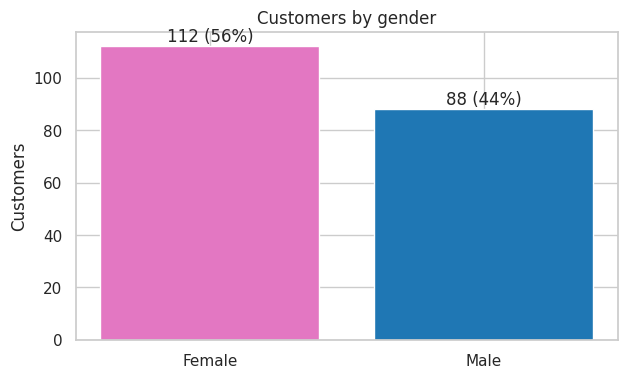

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df["Gender"].value_counts()
ax.bar(counts.index, counts.values, color=["tab:pink", "tab:blue"])
for i, v in enumerate(counts.values): ax.text(i, v + 2, f"{v} ({v/len(df):.0%})", ha="center")
ax.set(title="Customers by gender", ylabel="Customers"); save_fig("01_gender")

**Insight:** 112 women (56%) and 88 men (44%). Both groups are large enough to compare.

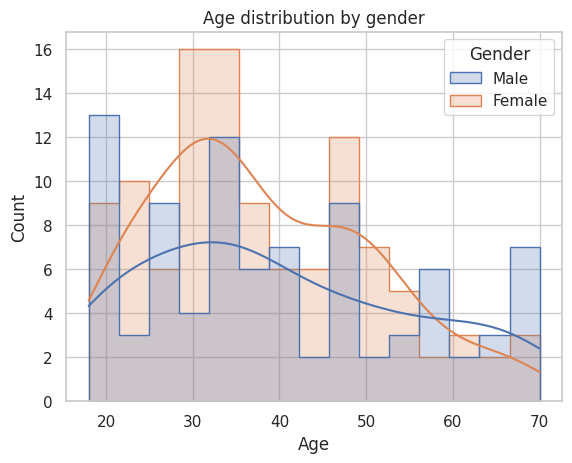

,Age,Income,Spending
Gender,,,
Female,38.098,59.250,51.527
Male,39.807,62.227,48.511


In [5]:
sns.histplot(data=df, x="Age", hue="Gender", kde=True, element="step", bins=15)
plt.title("Age distribution by gender"); save_fig("02_age")
df.groupby("Gender")[["Age", "Income", "Spending"]].mean()

**Insight:** members are 18–70 years old (median 36), with most in their 20s–40s. Women (38.1) and men (39.8) have almost the same average age.

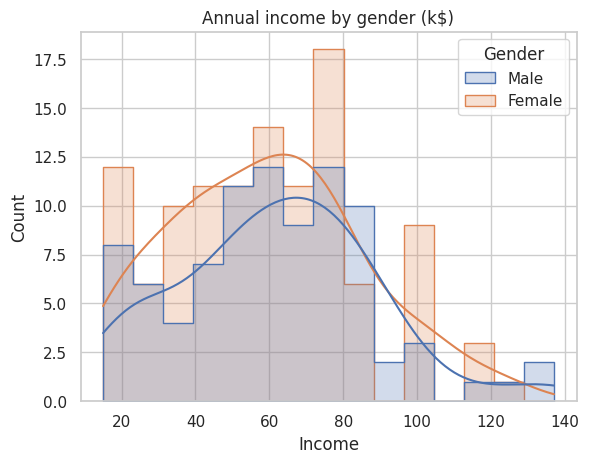

In [6]:
sns.histplot(data=df, x="Income", hue="Gender", kde=True, element="step", bins=15)
plt.title("Annual income by gender (k$)"); save_fig("03_income")

**Insight:** income ranges from 15 to 137 k$ (median 61.5). Men (62.2) and women (59.3) earn almost the same, so gender will not separate customers by income.

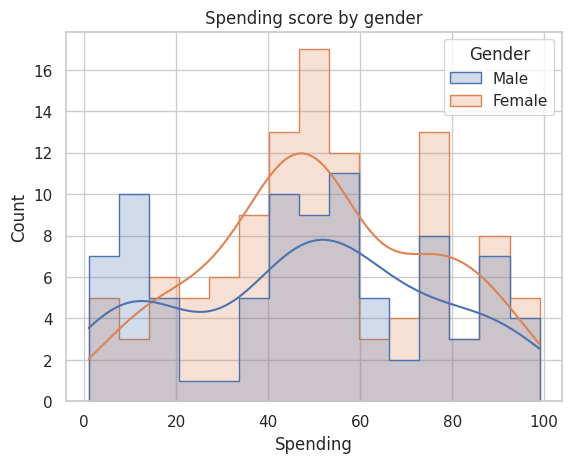

In [7]:
sns.histplot(data=df, x="Spending", hue="Gender", kde=True, element="step", bins=15)
plt.title("Spending score by gender"); save_fig("04_spending")

**Insight:** spending scores cover the whole 1–99 range, centred around 50. Women score slightly higher (51.5 vs 48.5), but the difference is small. **Gender is not a useful clustering feature**; we only report the gender mix of each cluster.

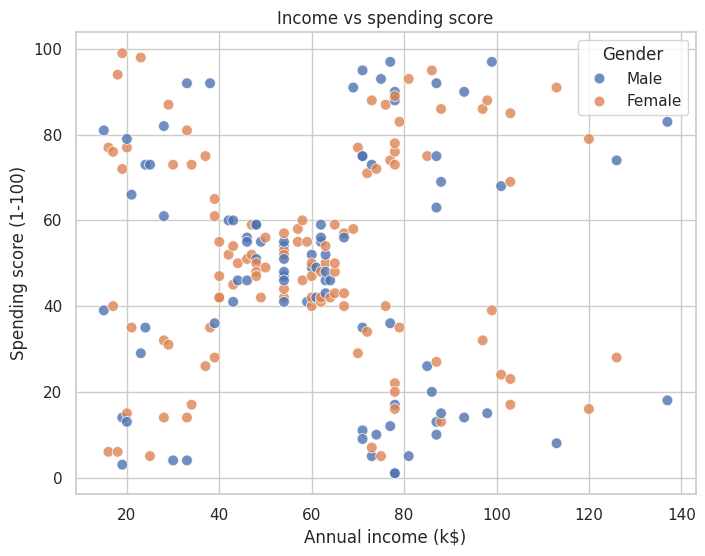

Correlation income vs spending: 0.01


In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Income", y="Spending", hue="Gender", s=60, alpha=0.8)
plt.title("Income vs spending score"); plt.xlabel("Annual income (k$)"); plt.ylabel("Spending score (1-100)")
save_fig("05_income_vs_spending")
print("Correlation income vs spending:", round(df["Income"].corr(df["Spending"]), 3))

**Insight:** the key chart. By eye there are about **five groups**: a dense middle group and four corners (low/low, low income–high spending, high/high, high income–low spending). The correlation is ~0.01: **income alone does not tell us how much someone spends**, which is exactly why segmentation is needed.

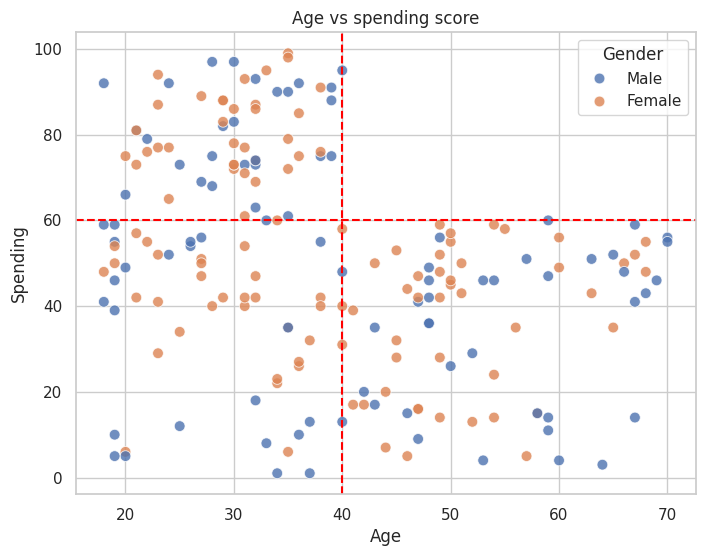

Customers with spending > 60: 62, of whom 100% are aged 40 or under
Correlation age vs spending: -0.327


In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Age", y="Spending", hue="Gender", s=60, alpha=0.8)
plt.axhline(60, color="red", ls="--"); plt.axvline(40, color="red", ls="--")
plt.title("Age vs spending score"); save_fig("06_age_vs_spending")
hi = df[df["Spending"] > 60]
print(f"Customers with spending > 60: {len(hi)}, of whom {(hi['Age'] <= 40).mean():.0%} are aged 40 or under")
print("Correlation age vs spending:", round(df["Age"].corr(df["Spending"]), 3))

**Insight:** every customer with a spending score above 60 is **40 or younger** (62 customers). Older members never reach high spending scores (correlation −0.33). Age matters for spending, which we test as an extra feature in section 7.

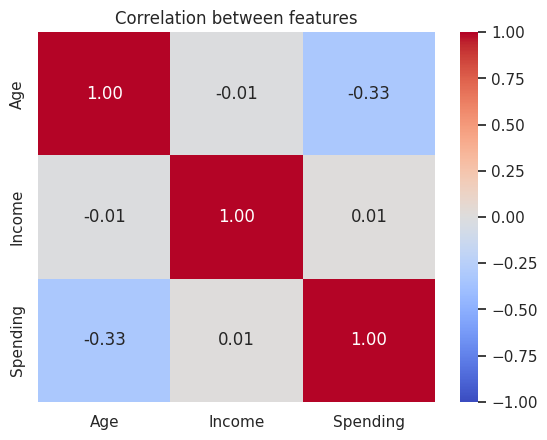

In [10]:
sns.heatmap(df[["Age", "Income", "Spending"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between features"); save_fig("07_correlation")

**Insight:** the three features are nearly independent (strongest: age–spending −0.33), so each adds different information. Correlation cannot show the **group** structure seen in the income–spending scatter, which is why we need clustering.

## 5. Feature preparation

In [11]:
features = ["Income", "Spending"]
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
print("Std before scaling:", df[features].std().round(2).to_dict())
print("Std after scaling :", pd.DataFrame(X, columns=features).std(ddof=0).round(2).to_dict())

Std before scaling: {'Income': 26.26, 'Spending': 25.82}
Std after scaling : {'Income': 1.0, 'Spending': 1.0}


- **Feature choice:** `Income` and `Spending`, the two dimensions marketing can act on and where the EDA showed clear groups. `Age` is tested separately in section 7; `Gender` is left out (little difference); `CustomerID` is an ID.
- **Scaling:** K-Means works with distances, so a feature with larger numbers would dominate. `StandardScaler` gives each feature mean 0 and std 1 so they count equally.
- **Encoding:** not needed (both features are numeric).
- **Leakage check:** there is no target in clustering, so there is no label to leak. We still make sure no ID or future information is used: only income and spending go into the model.

## 6. Modelling

In [12]:
# Baseline: a simple business rule — split customers at the median income and median spending (4 quadrants)
base_labels = ((df["Income"] > df["Income"].median()).astype(int) * 2 + (df["Spending"] > df["Spending"].median()).astype(int))
base_sil = silhouette_score(X, base_labels)
print(f"Baseline (median-split quadrants, 4 groups) silhouette: {base_sil:.3f}")

Baseline (median-split quadrants, 4 groups) silhouette: 0.332


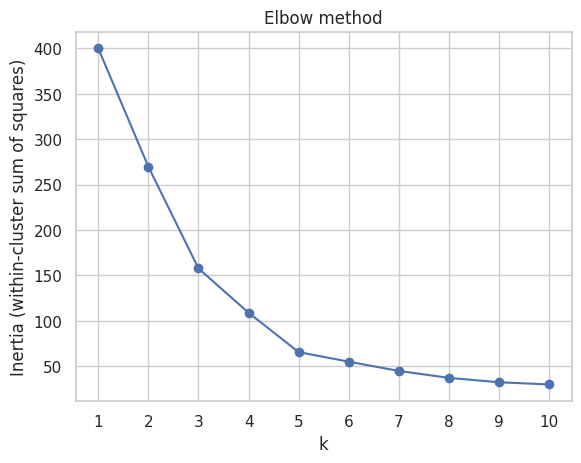

,k,Inertia,Drop
0,1,400.000,NaN
1,2,269.700,130.300
2,3,157.700,112.000
3,4,108.900,48.800
4,5,65.600,43.400
5,6,55.100,10.500
6,7,44.900,10.200
7,8,37.200,7.600
8,9,32.400,4.800
9,10,30.000,2.400


In [13]:
# Elbow method for k = 1..10 (random_state=42 for reproducibility)
inertia = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_ for k in range(1, 11)]
plt.plot(range(1, 11), inertia, "o-"); plt.xticks(range(1, 11))
plt.xlabel("k"); plt.ylabel("Inertia (within-cluster sum of squares)"); plt.title("Elbow method")
save_fig("08_elbow")
pd.DataFrame({"k": range(1, 11), "Inertia": inertia, "Drop": [None] + list(-np.diff(inertia))}).round(1)

**Insight:** inertia falls steeply up to **k = 5** (drops of 130, 112, 49, 43), then only by about 10 per extra cluster. The curve bends at 5, matching the five groups seen by eye.

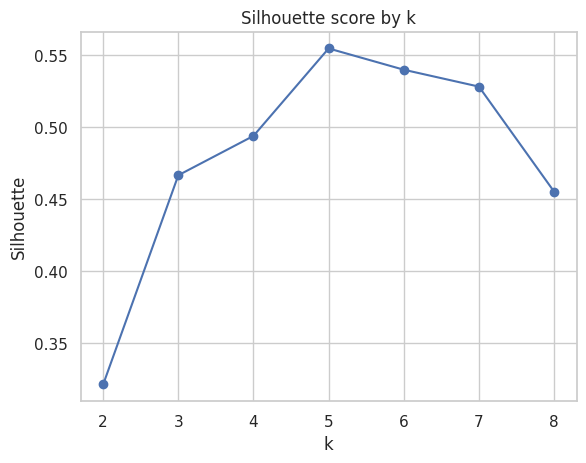

Best k by silhouette: 5


In [14]:
sil = {k: silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)) for k in range(2, 9)}
pd.Series(sil).plot(marker="o"); plt.xlabel("k"); plt.ylabel("Silhouette"); plt.title("Silhouette score by k")
save_fig("09_silhouette_k")
print("Best k by silhouette:", max(sil, key=sil.get))

**Insight:** silhouette is also highest at **k = 5 (0.555)**. Two independent methods agree, so we choose k = 5.

In [15]:
K = 5
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
km_sil = silhouette_score(X, df["Cluster"])
print(f"K-Means (k=5) silhouette: {km_sil:.3f}")

K-Means (k=5) silhouette: 0.555


## 7. Evaluation

In [16]:
pd.DataFrame({"Model": ["Baseline: median-split quadrants", "K-Means (k = 5)"],
              "Groups": [4, K], "Silhouette": [base_sil, km_sil]}).set_index("Model")

,Groups,Silhouette
Model,,
Baseline: median-split quadrants,4,0.332
K-Means (k = 5),5,0.555


**Result:** K-Means reaches a silhouette of **0.555** vs **0.332** for the simple median-split rule. The rule cuts straight through the natural groups (e.g. it splits the dense middle group into four pieces), while K-Means follows the real shape of the data.

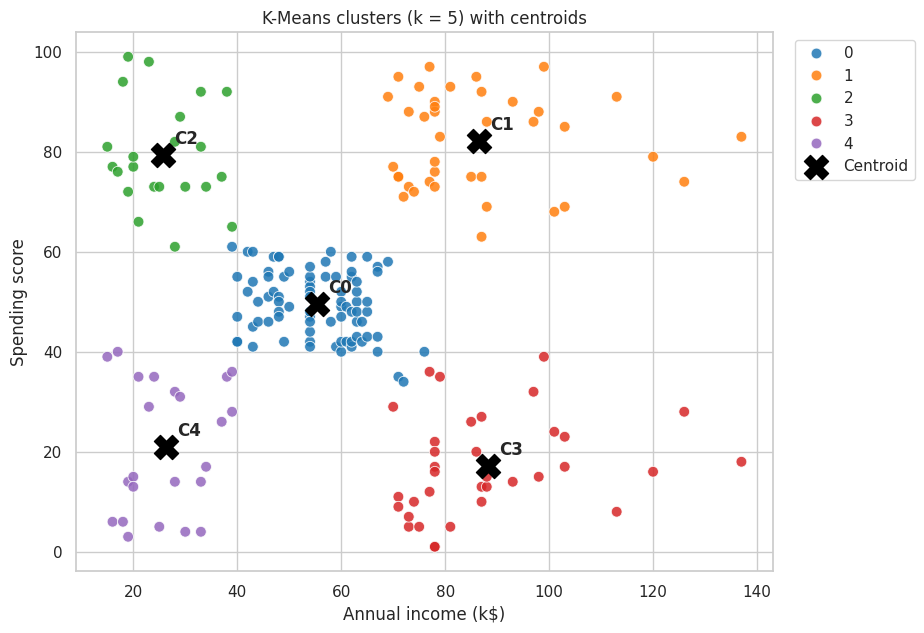

In [17]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x="Income", y="Spending", hue="Cluster", palette="tab10", s=60, alpha=0.85)
plt.scatter(centroids["Income"], centroids["Spending"], c="black", marker="X", s=300, label="Centroid")
for i, r in centroids.iterrows():
    plt.annotate(f"C{i}", (r["Income"], r["Spending"]), xytext=(8, 8), textcoords="offset points", weight="bold")
plt.title("K-Means clusters (k = 5) with centroids"); plt.xlabel("Annual income (k$)"); plt.ylabel("Spending score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); save_fig("10_clusters")

In [18]:
def level(v, col):
    m, s = df[col].mean(), df[col].std()
    return "High" if v > m + 0.5 * s else "Low" if v < m - 0.5 * s else "Mid"
personas = {("High", "High"): "Premium Spenders", ("High", "Low"): "Careful High Earners",
            ("Low", "High"): "Young Trend Seekers", ("Low", "Low"): "Budget-Conscious Shoppers",
            ("Mid", "Mid"): "Average Regulars"}
profile = df.groupby("Cluster").agg(Customers=("CustomerID", "count"), Mean_Age=("Age", "mean"),
                                    Mean_Income_k=("Income", "mean"), Mean_Spending=("Spending", "mean"),
                                    Female_pct=("Gender", lambda g: (g == "Female").mean() * 100))
profile["Persona"] = [personas.get((level(r.Mean_Income_k, "Income"), level(r.Mean_Spending, "Spending")), "Other")
                      for r in profile.itertuples()]
profile

,Customers,Mean_Age,Mean_Income_k,Mean_Spending,Female_pct,Persona
Cluster,,,,,,
0,81,42.716,55.296,49.519,59.259,Average Regulars
1,39,32.692,86.538,82.128,53.846,Premium Spenders
2,22,25.273,25.727,79.364,59.091,Young Trend Seekers
3,35,41.114,88.200,17.114,45.714,Careful High Earners
4,23,45.217,26.304,20.913,60.870,Budget-Conscious Shoppers


In [19]:
# Error analysis: which customers are poorly assigned? (silhouette per customer)
df["silhouette"] = silhouette_samples(X, df["Cluster"])
print(df.groupby("Cluster")["silhouette"].mean().round(3).rename("Mean silhouette"))
border = df[df["silhouette"] < 0.2]
print(f"\nBorderline customers (silhouette < 0.2): {len(border)}")
border.sort_values("silhouette")[["CustomerID", "Income", "Spending", "Cluster", "silhouette"]].head(9)

Cluster
0   0.598
1   0.511
2   0.598
3   0.505
4   0.511
Name: Mean silhouette, dtype: float64

Borderline customers (silhouette < 0.2): 9


,CustomerID,Income,Spending,Cluster,silhouette
146,147,77,36,3,-0.029
42,43,39,36,4,-0.012
124,125,70,29,3,0.008
45,46,39,65,2,0.050
40,41,38,35,4,0.091
160,161,79,35,3,0.097
132,133,72,34,0,0.116
43,44,39,61,0,0.121
142,143,76,40,0,0.198


**Error analysis:** every cluster has a mean silhouette above 0.5. Only **9 of 200 customers** are borderline (silhouette < 0.2). They sit between the middle group and a corner group, so marketing should not treat their persona as certain.

In [20]:
# Stability: does the result change with a different random_state?
for seed in [0, 1, 7, 99]:
    other = KMeans(n_clusters=K, n_init=10, random_state=seed).fit_predict(X)
    print(f"random_state={seed:>2}: Adjusted Rand Index vs 42 = {adjusted_rand_score(df['Cluster'], other):.3f}")

random_state= 0: Adjusted Rand Index vs 42 = 1.000
random_state= 1: Adjusted Rand Index vs 42 = 1.000
random_state= 7: Adjusted Rand Index vs 42 = 1.000
random_state=99: Adjusted Rand Index vs 42 = 1.000


**Stability:** ARI = 1.000 for every seed, so the groups are identical; only the cluster numbers may change.

In [21]:
# Stretch: add Age as a third feature
X3 = StandardScaler().fit_transform(df[["Age", "Income", "Spending"]])
sil3 = {k: silhouette_score(X3, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X3)) for k in range(2, 9)}
k3 = max(sil3, key=sil3.get)
df["Cluster3"] = KMeans(n_clusters=k3, n_init=10, random_state=42).fit_predict(X3)
print(f"3 features: best k = {k3}, silhouette = {sil3[k3]:.3f} (vs {km_sil:.3f} with 2 features)")
print("Agreement with 2-feature clusters (ARI):", round(adjusted_rand_score(df["Cluster"], df["Cluster3"]), 3))
df.groupby("Cluster3")[["Age", "Income", "Spending"]].mean().round(1).assign(Customers=df["Cluster3"].value_counts().sort_index())

3 features: best k = 6, silhouette = 0.428 (vs 0.555 with 2 features)
Agreement with 2-feature clusters (ARI): 0.7


,Age,Income,Spending,Customers
Cluster3,,,,
0,56.300,54.300,49.100,45
1,26.800,57.100,48.100,39
2,41.900,88.900,17.000,33
3,32.700,86.500,82.100,39
4,25.000,25.300,77.600,23
5,45.500,26.300,19.400,21


**Stretch result:** with Age, silhouette is best at k = 6 but lower (**0.428**). The main change is that the middle group splits into older (~56) and younger (~27) customers. The 2-feature version is clearer, so we keep it and use age only to choose the channel.

## 8. Conclusion & recommendation
**Answer to the business question:** the mall's 200 members form **five clear groups** based on income and spending score (silhouette 0.555 vs 0.332 for a simple median split).

| Persona | Customers | Avg age | Avg income | Avg spending | Campaign |
|---|---|---|---|---|---|
| **Average Regulars** | 81 | 43 | 55 k$ | 50 | Points-based loyalty card, seasonal (Eid / year-end) offers |
| **Premium Spenders** | 39 | 33 | 87 k$ | 82 | VIP tier: early access, private sale nights, free valet (**retain**) |
| **Young Trend Seekers** | 22 | 25 | 26 k$ | 79 | Social-media flash deals, student discounts |
| **Careful High Earners** | 35 | 41 | 88 k$ | 17 | Personal shopper, premium-brand trials (**convert**) |
| **Budget-Conscious Shoppers** | 23 | 45 | 26 k$ | 21 | Coupon book, value bundles, weekday discounts |

**Recommendation:** replace the single promotion with five targeted campaigns. Put the **largest extra budget into Careful High Earners** (high income, low spending → biggest growth potential) and protect **Premium Spenders** with a low-cost VIP programme.

**Limitations:** only 200 customers and 4 columns; the spending score is a mall-made index whose formula we do not know; clusters describe *who* customers are, not *why* they spend; 9 borderline customers.

**Next steps:** add visit frequency and product categories; A/B-test each campaign for 3 months; re-run the clustering every quarter.

### Viva notes
1. **Why scale?** K-Means uses distance; otherwise the feature with bigger numbers dominates.
2. **Why k = 5?** Elbow bends at 5 and silhouette is highest at 5 (0.555); k = 4 merges two different groups, k = 6 only splits the middle group.
3. **Centroid in business terms:** the typical customer of a group, e.g. Careful High Earners ≈ 88 k$ income, spending score 17.
4. **Different random_state?** Same groups (ARI = 1.000); only the numbers may be renamed.
5. **Where to spend most?** Careful High Earners (growth) while retaining Premium Spenders (value).